In [ ]:
### IMPORTS ###

In [1]:
import scanpy as sc
import pandas as pd
import liana as li

In [2]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean


In [ ]:
### LOAD ###

In [3]:
# 1 Load mapped AnnData #
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 75467 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [4]:
# Prepare #
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
adata = adata[adata.obs["Phenograph"].notna()].copy()
adata = adata[:, adata.var["ORTHOLOG_HUMAN_SYMBOL"].notna()].copy()
adata.var_names = adata.var["ORTHOLOG_HUMAN_SYMBOL"].astype(str)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33985 × 16028
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [5]:
# Full cross-tabulation: stage × Phenograph
crosstab = pd.crosstab(
    adata.obs["Stages"],
    adata.obs["Phenograph"]
)

stage_order = ["st08", "st10.5", "st12", "st13", "st16", "st18", "st20", "st22", "st24", "st27"]
crosstab = crosstab.reindex(stage_order)

print("=== Cells per Stage × Phenograph ===")
print(crosstab.to_string())

=== Cells per Stage × Phenograph ===
Phenograph  Bc1  Bc2   Bc3   Bc4  Eep1  Eep2  Eep3  Eep4    Gc   Ic  Mcc2  Mcc3  Mcc/CCPs    P1    P2
Stages                                                                                               
st08          0    0     0     0    31     0     0     0     0    0     0     0         0    93  3284
st10.5        0    0     0     0     0     0     0     0     0    0     0     0         0  1108   153
st12          0    0     0     0    19     0     0     0     0    0     0     0         0   848     1
st13          6    0     0     0  2698  1195    78   531     0    0   127     0      1150     4    34
st16          2    0     0     0   874  1097   211   353     0    0   250     0       453     0    12
st18         13   41     0     1   100   775  1896   799    19    9   511     6        58     0     0
st20         37   24     0     0   132   640  1312   702     2    3   520     6        68     0     4
st22        671  290  2121   102    12     8 

In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

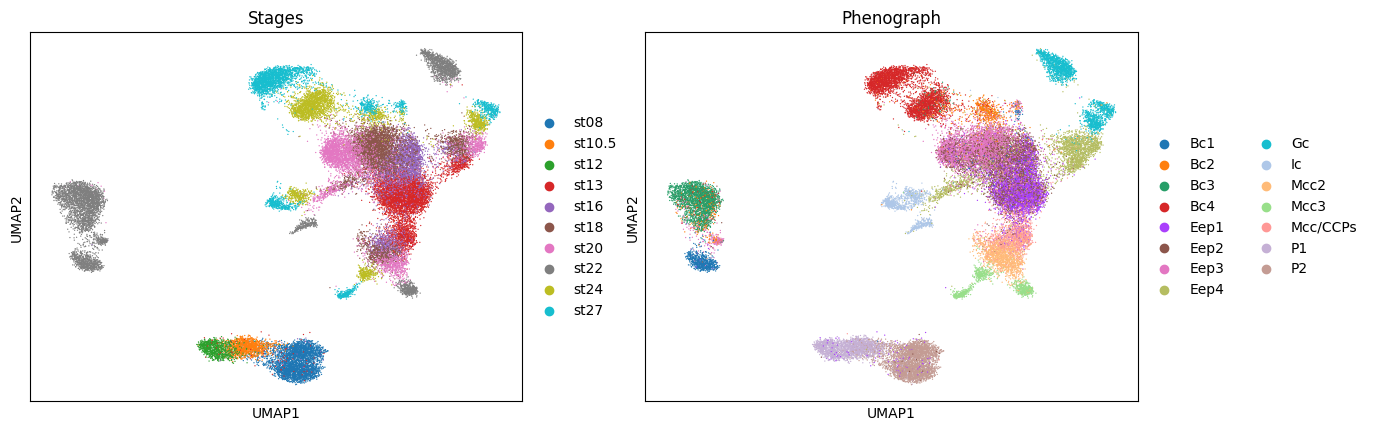

In [7]:
sc.pl.umap(adata, color=["Stages", "Phenograph"])

In [8]:
# 2 Load and parse Table S7 signaling file #
import pandas as pd

tsv_file = "TableS7-Signalling_StageClusters.tsv"

def parse_signalling_tsv(tsv_file):
    records = []
    current_pathway = None

    with open(tsv_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # Detect pathway section headers
            if line.startswith("##"):
                current_pathway = line.replace("##", "").strip()
                continue
            elif line.startswith("#"):
                current_pathway = line.replace("#", "").strip()
                continue

            # Skip repeated column headers
            if line.startswith("Gene\t"):
                continue

            parts = line.split("\t")
            if len(parts) >= 3:
                records.append({
                    "pathway": current_pathway,
                    "xeno_symbol": parts[0],
                    "cell_type": parts[1],
                    "stage": parts[2]
                })

    return pd.DataFrame(records)

# Parse once
signalling_df = parse_signalling_tsv(tsv_file)

# Quick summary per pathway
for pathway in signalling_df["pathway"].dropna().unique():
    df = signalling_df[signalling_df["pathway"] == pathway]

    print(f"\n=== {pathway} ===")
    print(f"Unique genes: {df['xeno_symbol'].nunique()}")
    print(f"Unique cell types: {df['cell_type'].nunique()}")
    print(f"Unique stages: {df['stage'].nunique()}")


=== Notch ===
Unique genes: 49
Unique cell types: 10
Unique stages: 9

=== Wnt ===
Unique genes: 138
Unique cell types: 14
Unique stages: 10

=== TGF-B ===
Unique genes: 66
Unique cell types: 12
Unique stages: 9


In [ ]:
### NOTCH ###

In [9]:
notch_table = signalling_df.loc[signalling_df["pathway"] == "Notch"].copy()
notch_table.head()

,pathway,xeno_symbol,cell_type,stage
0,Notch,aph1a.S,P2,st08
1,Notch,ctbp2.S,P2,st08
2,Notch,ctbp1.S,P2,st08
3,Notch,psen2.S,P2,st08
4,Notch,dtx2.L,P1,st10.5


In [10]:
# Map Xenopus symbols to human orthologs for NOTCH #
gene_map = (
    adata.var[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .dropna(subset=["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"])
    .drop_duplicates()
    .copy()
)

notch_found = (
    notch_table
    .merge(gene_map, on="xeno_symbol", how="inner")
    [["stage", "cell_type", "xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .sort_values(["stage", "cell_type", "xeno_symbol"])
    .reset_index(drop=True)
)

notch_found

,stage,cell_type,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
0,st08,P2,aph1a.S,APH1A
1,st08,P2,ctbp1.S,CTBP1
2,st08,P2,ctbp2.S,CTBP2
3,st08,P2,psen2.S,PSEN2
4,st10.5,Gc,adam17.S,ADAM17
5,st10.5,P1,dtx2.L,DTX2
6,st10.5,P1,jag1.L,JAG1
7,st10.5,P1,maml1.L,MAML1
8,st10.5,P1,rbpj.L,RBPJ
9,st10.5,P2,jag1.S,JAG1


In [ ]:
### LIANA ###

In [11]:
# Subset to stage 22 #
adata_st22 = adata[adata.obs["Stages"] == "st22"].copy()

print(adata.shape)
print(adata_st22.shape)
adata_st22.var_names[:10]

(33985, 16028)
(5217, 16028)


Index(['SUCLG1', 'ADRA1D', 'SMOX', 'RNF24', 'GNRH2', 'AVP', 'UBOX5', 'LZTS3',
       'ATRN', 'SLC4A11'],
      dtype='object', name='ORTHOLOG_HUMAN_SYMBOL')

In [12]:
adata_st22.var_names.name = None

In [13]:
print("=== Stage 22 cells per Phenograph ===")
print(
    adata_st22.obs["Phenograph"]
    .value_counts()
    .sort_index()
    .to_string()
)

=== Stage 22 cells per Phenograph ===
Phenograph
Bc1          671
Bc2          290
Bc3         2121
Bc4          102
Eep1          12
Eep2           8
Eep3         217
Eep4          20
Gc          1159
Ic           239
Mcc2          14
Mcc3         363
Mcc/CCPs       1


In [14]:
# CellPhoneDB #
cellphonedb(
    adata_st22,
    groupby='Phenograph',
    resource_name='consensus',
    expr_prop=0.01,
    verbose=True,
    key_added='cpdb_res',
    use_raw=False
)
adata_st22.uns["cpdb_res"].head()


Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Mcc/CCPs
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5216 samples and 560 features


100%|██████████| 1000/1000 [00:01<00:00, 649.62it/s]


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
4376,MDK,MDK,0.160228,0.395568,NCL,NCL,1.332486,0.916667,Bc3,Eep1,0.746357,0.000
4381,MDK,MDK,0.107987,0.205882,NCL,NCL,1.332486,0.916667,Bc4,Eep1,0.720236,0.000
4368,MDK,MDK,0.103619,0.203448,NCL,NCL,1.332486,0.916667,Bc2,Eep1,0.718052,0.000
4383,MDK,MDK,0.091678,0.125000,NCL,NCL,1.332486,0.916667,Eep2,Eep1,0.712082,0.003
4361,MDK,MDK,0.084624,0.296572,NCL,NCL,1.332486,0.916667,Bc1,Eep1,0.708555,0.000


In [15]:
cpdb = adata_st22.uns["cpdb_res"]

print(sorted(cpdb["source"].unique()))
print(sorted(cpdb["target"].unique()))


['Bc1', 'Bc2', 'Bc3', 'Bc4', 'Eep1', 'Eep2', 'Eep3', 'Eep4', 'Gc', 'Ic', 'Mcc2', 'Mcc3']
['Bc1', 'Bc2', 'Bc3', 'Bc4', 'Eep1', 'Eep2', 'Eep3', 'Eep4', 'Gc', 'Ic', 'Mcc2', 'Mcc3']


In [16]:
print("CPDB interactions:", adata_st22.uns["cpdb_res"].shape[0])

CPDB interactions: 6543


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


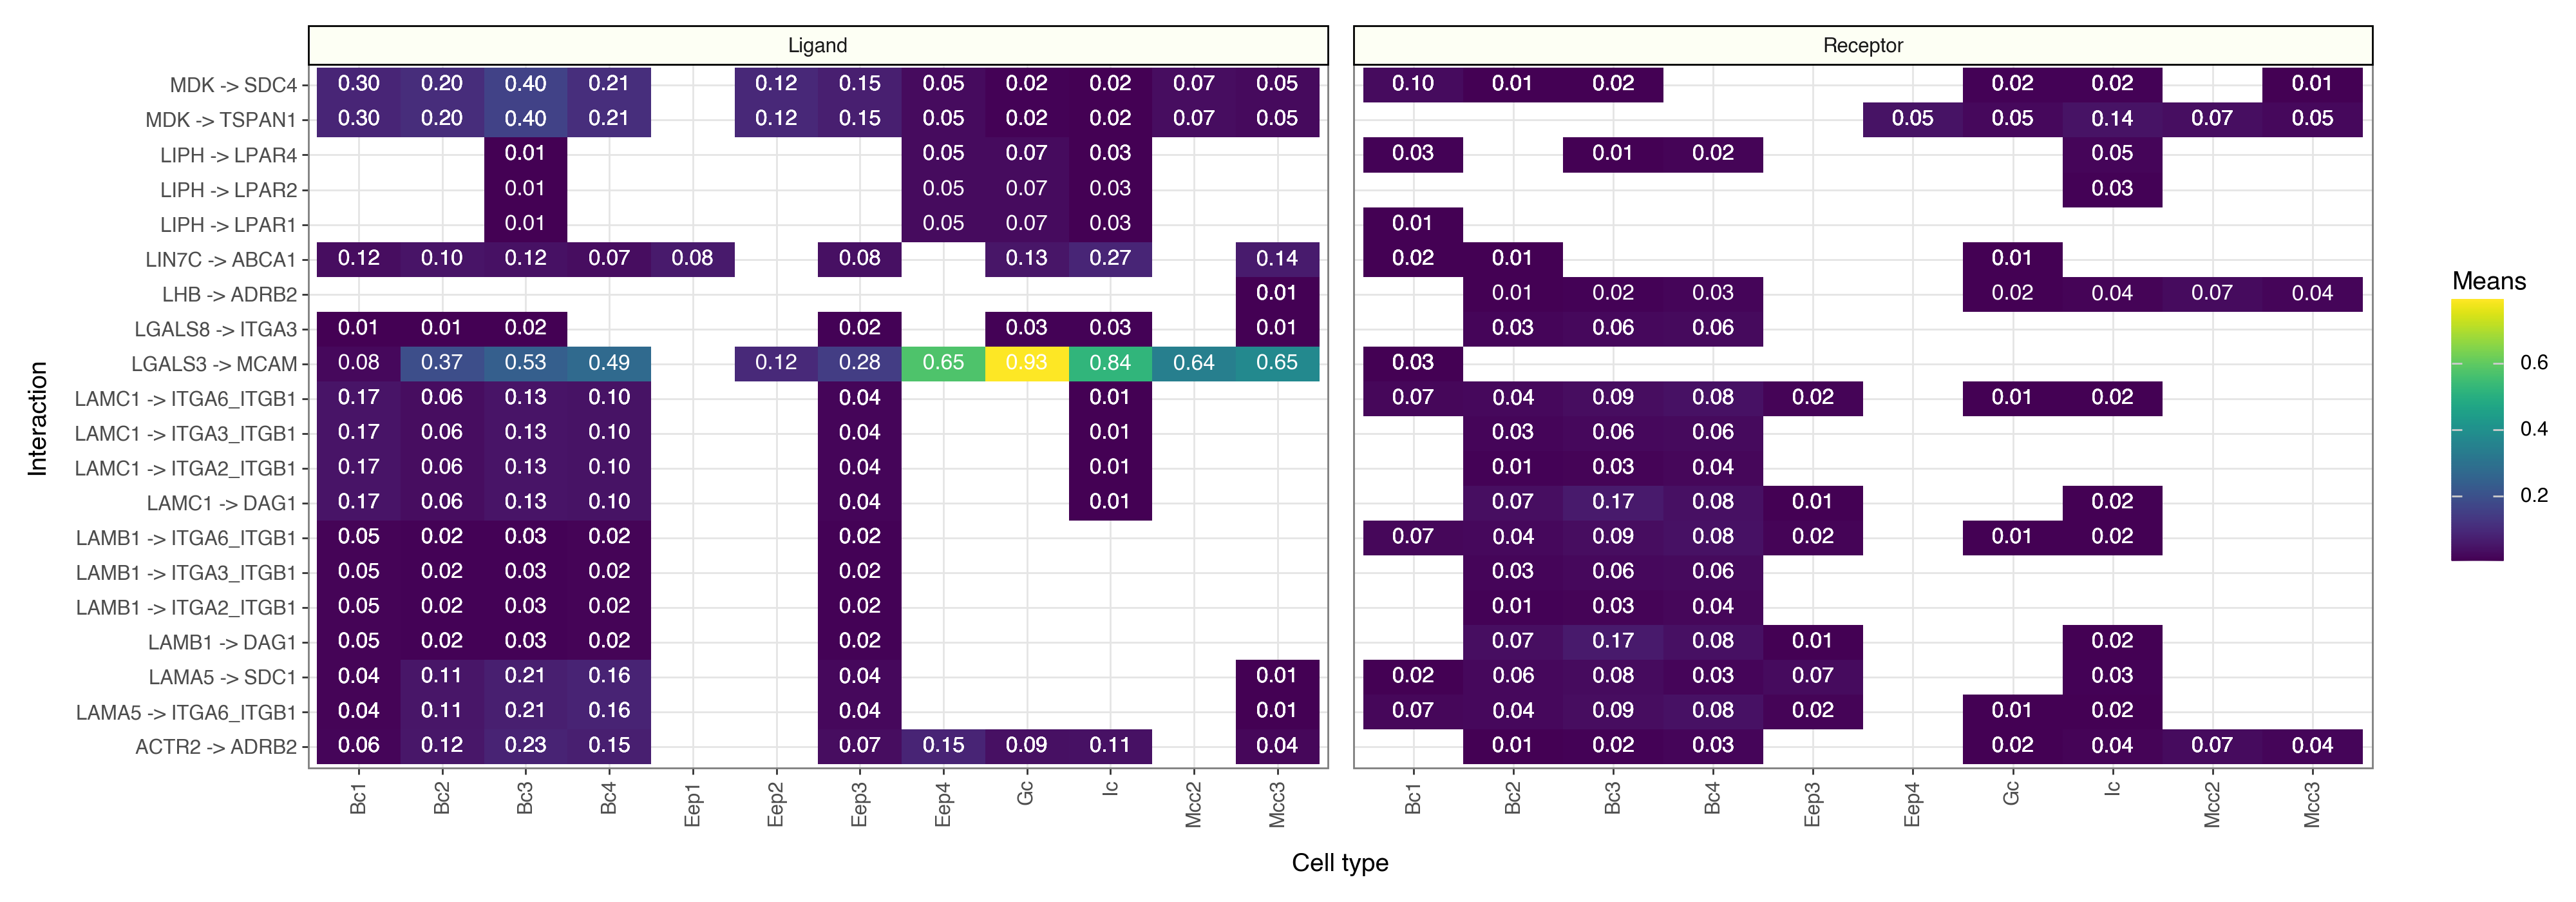

In [ ]:
tile_p = li.pl.tileplot(
    adata=adata_st22,
    uns_key="cpdb_res",
    fill="means",
    label="props",
    label_fun=lambda x: f"{x:.2f}",
    top_n=20,
    orderby="cellphone_pvals",
    orderby_ascending=True,
    source_labels=sorted(cpdb["source"].unique()),
    target_labels=sorted(cpdb["target"].unique()),
    source_title="Ligand",
    target_title="Receptor",
    figure_size=(20, 7)
)
tile_p
tile_p.save('st22_top20_liana_cpdb_tileplot.png')

In [ ]:
## RESULT ##
# The tileplot shows the CellPhoneDB (cpdb_res) support for the top stage-22 interactions by displaying ligand-side and receptor-side expression separately.Here, the colour scale (means) shows the average expression level of the ligand or receptor in each cluster, while the numbers printed inside the tiles (props) indicate the proportion of cells in that cluster expressing that ligand or receptor. For example, a value such as 0.93 means that about 93% of cells in that cluster express that gene or complex. 
# Biologically, this helps distinguish broadly expressed interactions from more cluster-restricted signals. 
# In stage 22, this is useful because the tissue is already specialized into basal, goblet, ionocyte, and multiciliated states, but these populations are still maturing and organizing, so some interactions are broad epithelial signals whereas others are more lineage- or cluster-specific.

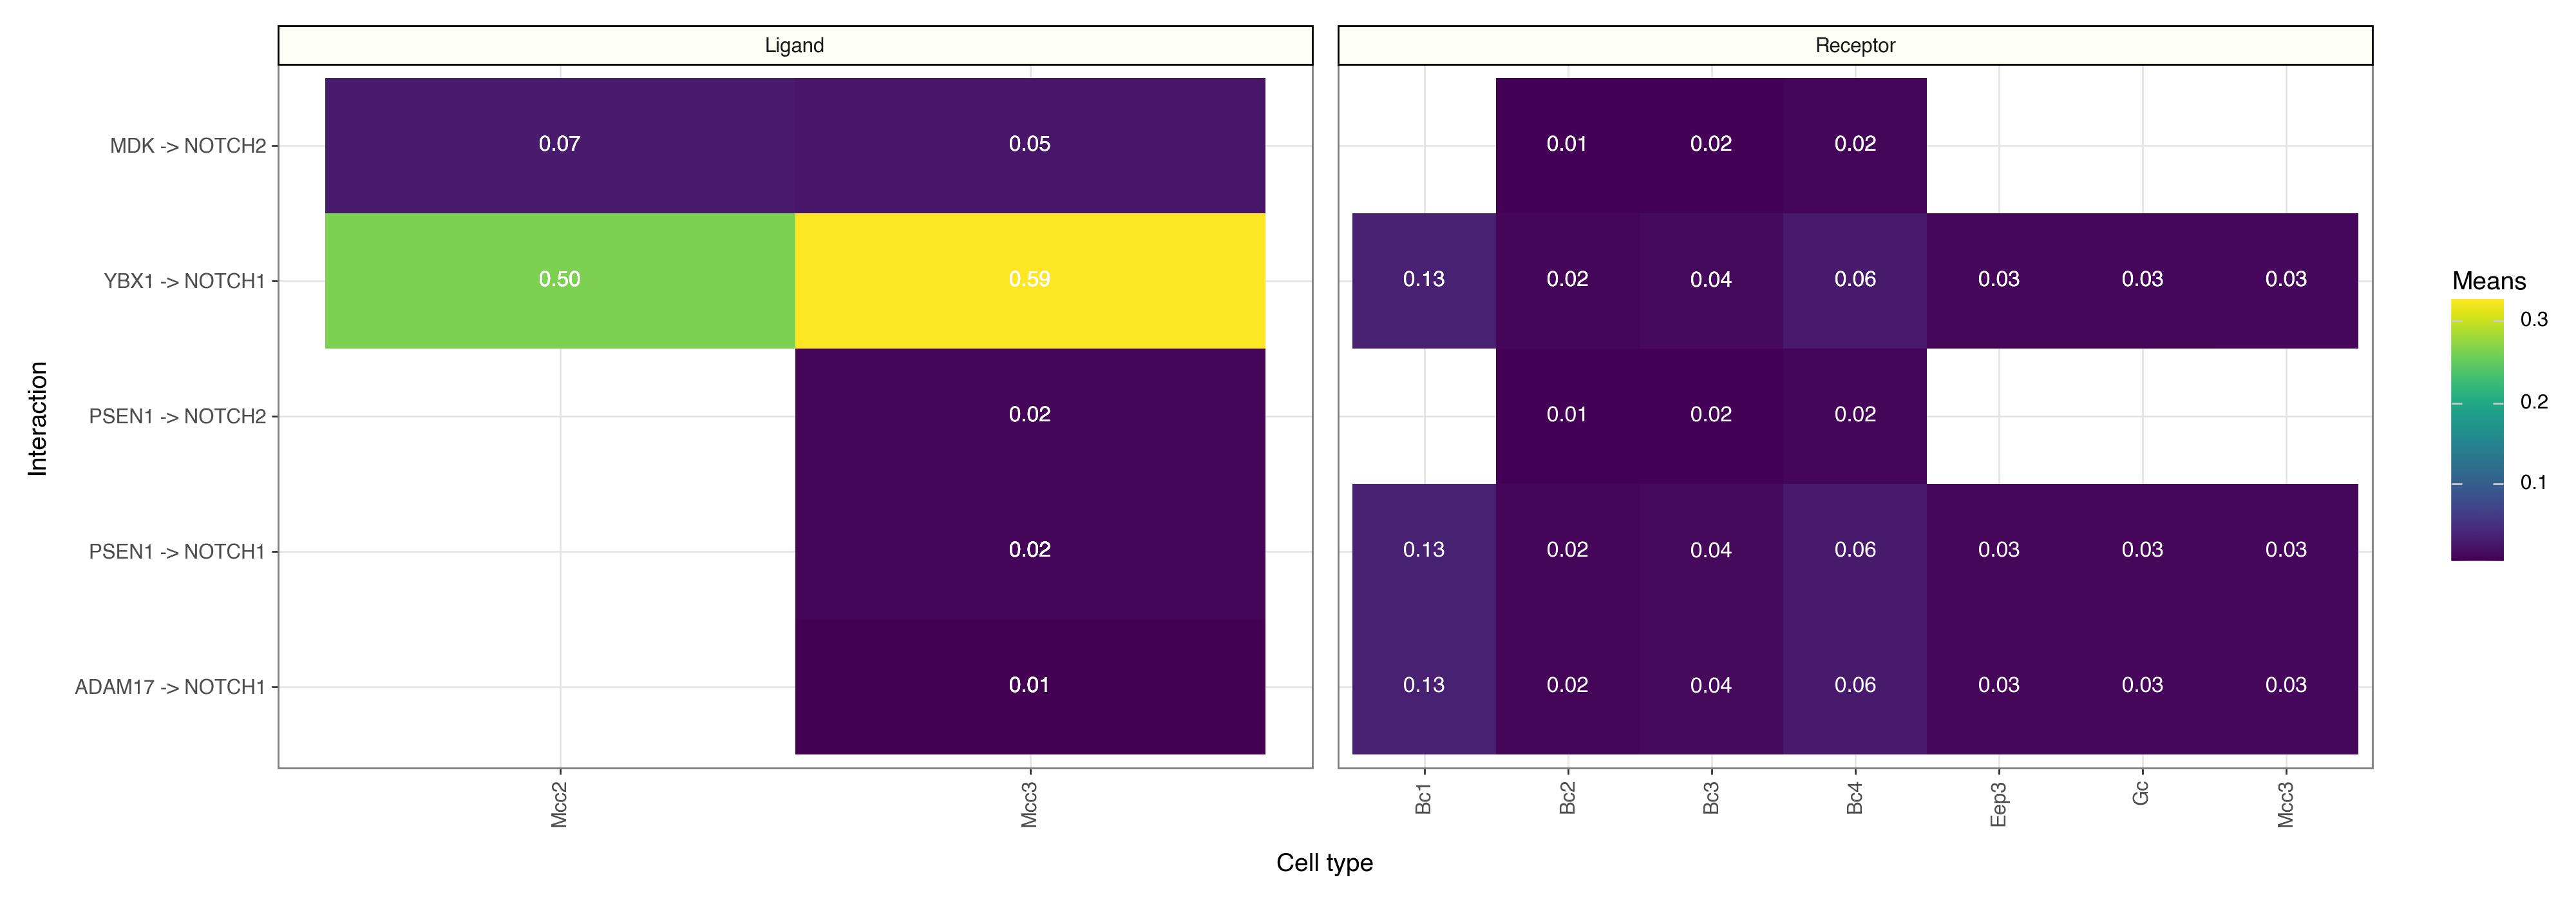

In [ ]:
tile_p_notch = li.pl.tileplot(
    adata=adata_st22,
    uns_key="cpdb_res",
    fill="means",
    label="props",
    label_fun=lambda x: f"{x:.2f}",
    top_n=20,
    orderby="cellphone_pvals",
    orderby_ascending=True,
    source_labels=["Mcc2", "Mcc3"] if set(["Mcc2", "Mcc3"]).issubset(set(cpdb["source"].unique())) else sorted(cpdb["source"].unique()),
    target_labels=sorted(cpdb["target"].unique()),
    filter_fun=lambda x: x["receptor_complex"] in ["NOTCH1", "NOTCH2"],
    source_title="Ligand",
    target_title="Receptor",
    figure_size=(20, 7)
)
tile_p_notch
tile_p_notch.save('st22_notch_tileplot.png')

In [ ]:
### RESULTS ###
# This tileplot shows the CellPhoneDB-derived expression support for selected stage 22 Notch-associated interactions. 
# In this filtered view, YBX1 → NOTCH1 shows the strongest ligand-side support among the selected multiciliated sources (Mcc2, Mcc3), whereas other interactions such as MDK → NOTCH2, PSEN1 → NOTCH1/2, and ADAM17 → NOTCH1 show weaker expression support.
# The tileplot suggests that when the analysis is restricted to multiciliated sources, the strongest expression-supported Notch-associated signal is YBX1 → NOTCH1. However, this should be interpreted cautiously, since it is less canonical than DLL1/JAG1-driven Notch signaling. 
# Overall, the tileplot supports the idea that multiciliated clusters may contribute some Notch-adjacent signaling, but the broader and more classical Notch story at stage 22 appears to remain more strongly associated with basal-related clusters than with multiciliated cells.

In [19]:
# Rank Aggregate #
li.mt.rank_aggregate(
    adata_st22,
    groupby='Phenograph',
    resource_name='consensus',
    expr_prop=0.01,
    verbose=True,
    use_raw=False
)


Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Mcc/CCPs
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5216 samples and 560 features
Assuming that counts were `natural` log-normalized!


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:01<00:00, 669.22it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [20]:
print(adata_st22.uns.keys())

odict_keys(['log1p', 'pca', 'neighbors', 'umap', 'Stages_colors', 'Phenograph_colors', 'cpdb_res', 'liana_res'])


In [21]:
res = adata_st22.uns["liana_res"]
print(res.columns)


Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [22]:
print("LIANA interactions:", adata_st22.uns["liana_res"].shape[0])

LIANA interactions: 6543


In [23]:
adata_st22.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2224,Bc3,Eep1,MDK,NCL,0.746357,0.000,0.213501,0.626722,0.399117,0.027192,0.966337,0.009079,2.102056e-07
1727,Bc3,Bc1,MDK,NCL,0.698018,0.000,0.198011,0.510878,0.292402,0.025219,0.965090,0.009079,1.029378e-05
3053,Bc4,Eep1,MDK,NCL,0.720236,0.000,0.143892,0.485369,0.320155,0.018327,0.959294,0.009079,1.344357e-05
1301,Bc2,Eep1,MDK,NCL,0.718052,0.000,0.138071,0.473549,0.317812,0.017585,0.958480,0.009079,1.701278e-05
2689,Bc4,Bc1,MDK,NCL,0.671898,0.000,0.133452,0.369525,0.213440,0.016997,0.957798,0.009079,2.540897e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,Bc1,Ic,GNAI2,ADCY9,0.007750,0.007,0.000060,0.165301,0.005498,0.035555,0.324918,0.199485,1.000000e+00
3219,Bc4,Ic,GNAI2,ADCY9,0.008598,0.072,0.000073,0.181472,0.007993,0.043147,0.346491,0.123014,1.000000e+00
3240,Bc4,Ic,LTBP1,ITGB5,0.007024,0.052,0.000045,0.131142,0.007912,0.123767,0.295124,0.125547,1.000000e+00
3200,Bc4,Ic,ADAM10,AXL,0.014266,0.007,0.000095,0.215435,0.017753,0.183743,0.376841,0.020799,1.000000e+00


In [24]:
# Save st22 outputs - adata + LIANA (rank aggregate + CellPhoneDB) #
adata_st22.write_h5ad("adata_st22_liana_phenograph.h5ad")
adata_st22.uns["liana_res"].to_csv("st22_liana_res_phenograph.csv", index=False)
adata_st22.uns["cpdb_res"].to_csv("st22_cpdb_res_phenograph.csv", index=False)

print("Saved stage 22 Phenograph outputs.")

Saved stage 22 Phenograph outputs.


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


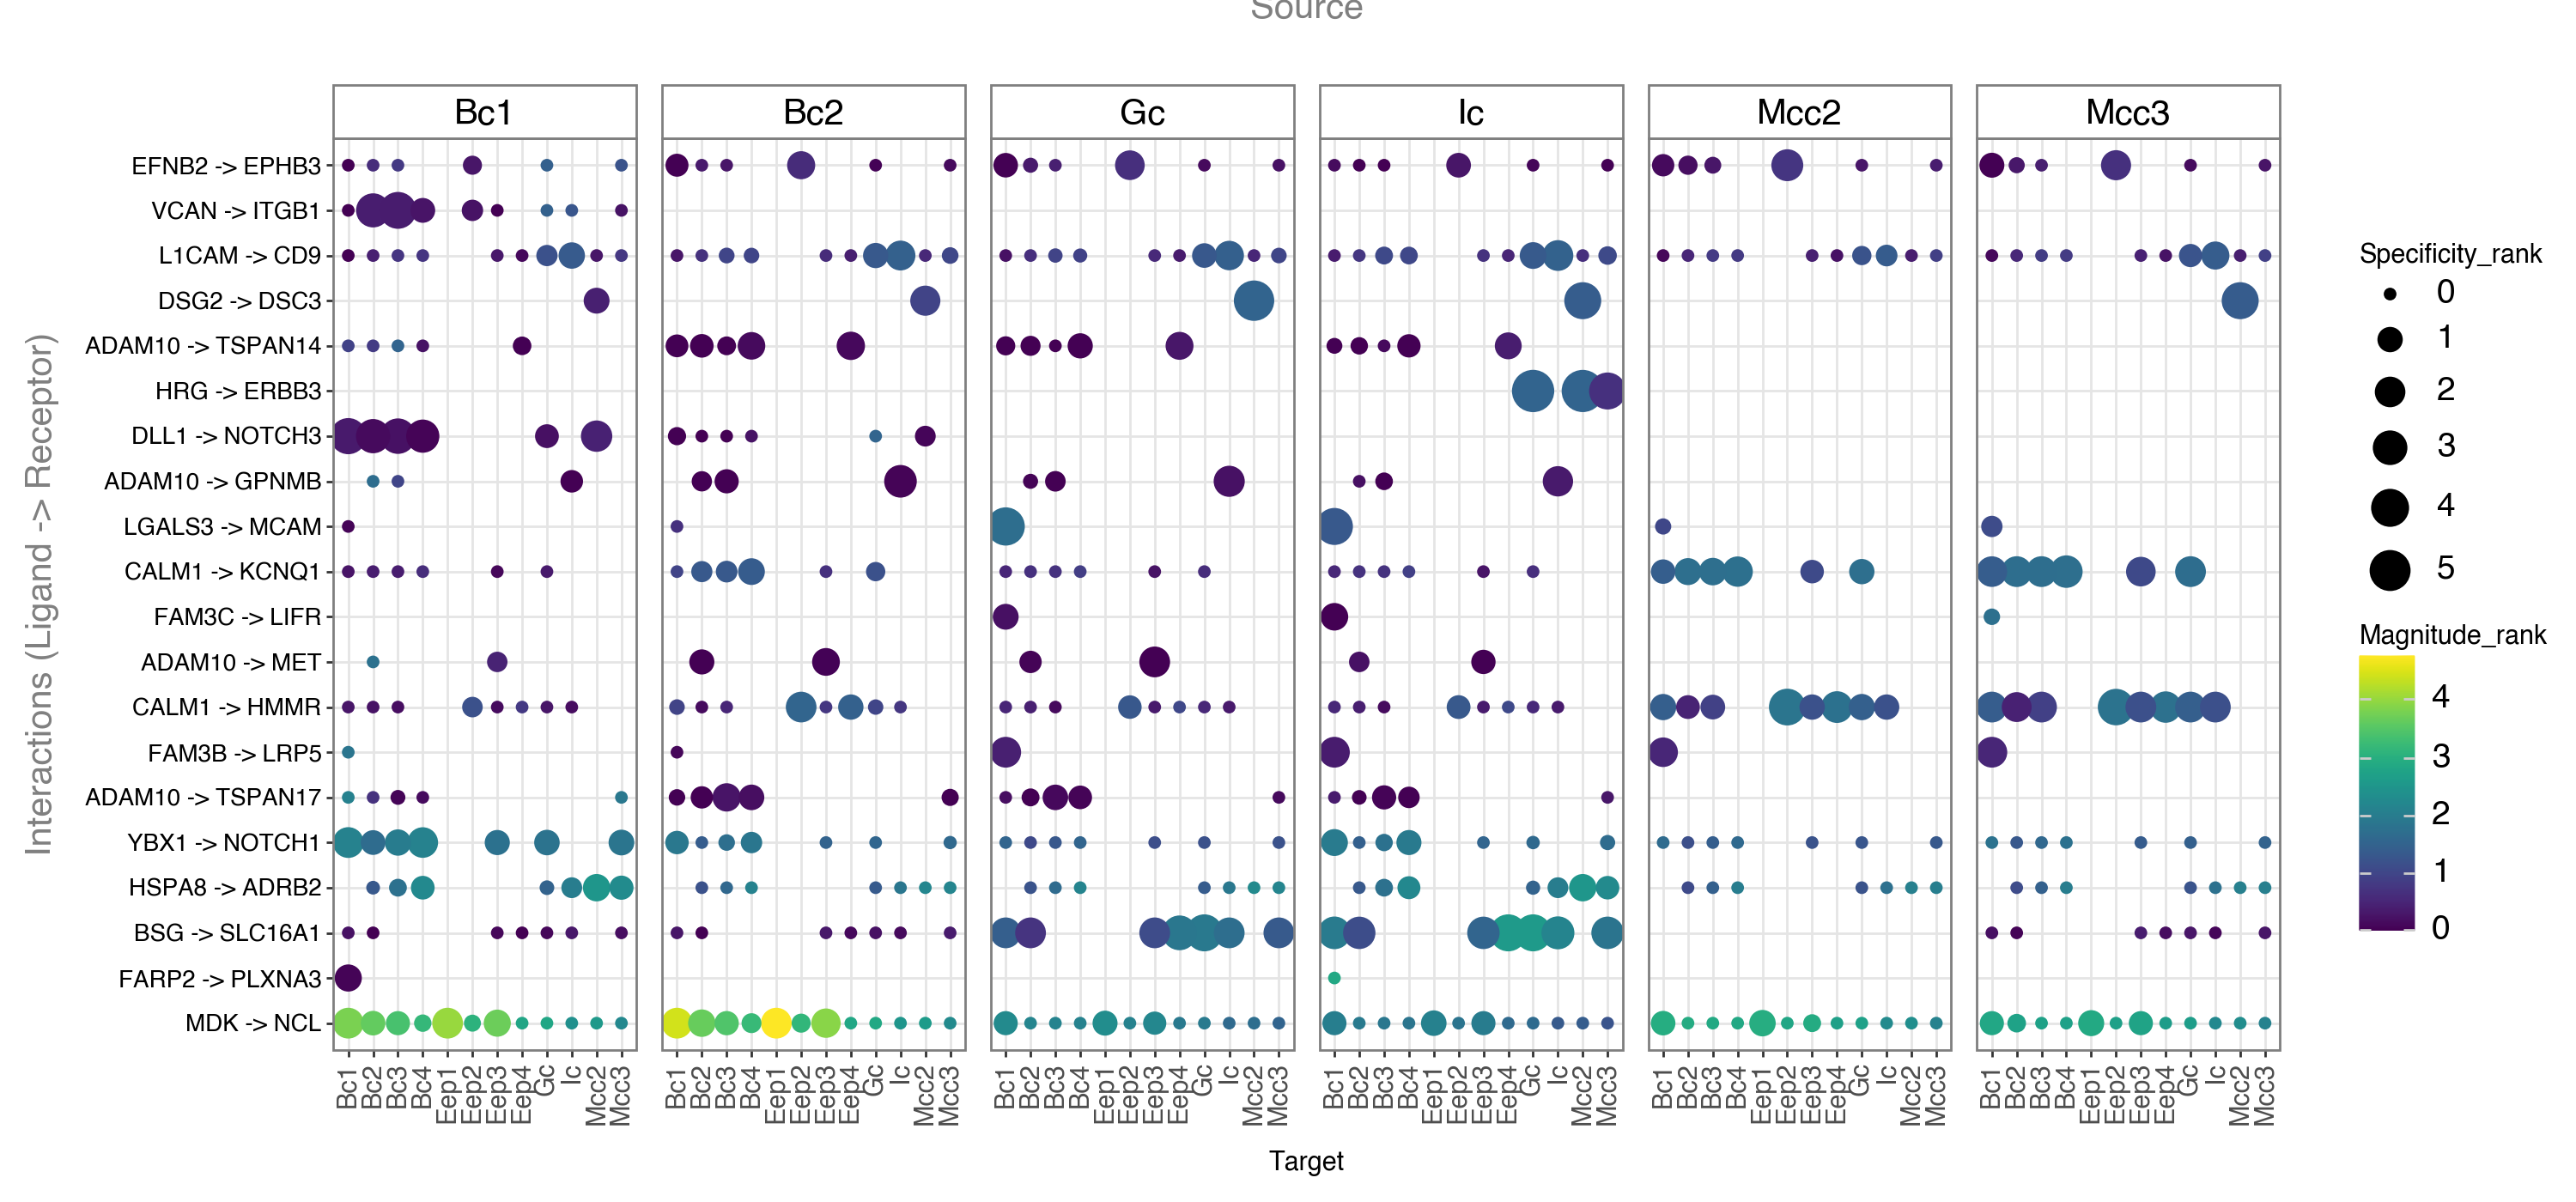

In [ ]:
# DOTPLOT liana_res #
dot_p = li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    source_labels=["Mcc2", "Mcc3", "Ic", "Gc", "Bc1", "Bc2"],
    top_n=20,
    orderby="magnitude_rank",
    orderby_ascending=True,
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    figure_size=(15, 7)
)
dot_p
dot_p.save('st22_top20_dotplot.png')

In [ ]:
## RESULT ##
# This dotplot summarizes the top stage-22 ligand–receptor interactions from LIANA rank aggregate, which integrates evidence across multiple CCC methods. In this plot, colour reflects magnitude_rank and dot size reflects specificity_rank, so the larger and brighter dots indicate interactions that are ranked as stronger and more specific across methods. 
# Biologically, the stage-22 landscape suggests that basal-related subclusters (Bc1, Bc2) remain interaction-rich, while goblet (Gc), ionocyte (Ic), and multiciliated (Mcc2, Mcc3) clusters participate in more restricted but still meaningful signaling. 
# This fits the Xenopus paper, where tailbud stages mark specialization into basal, goblet, ionocyte, and multiciliated states, with basal subclusters remaining heterogeneous and biologically active. Canonical developmental signals such as Notch-related interactions are present, but they appear within a broader communication landscape that also includes adhesion-, ECM-, and trophic-type interactions.

In [ ]:
### NOTCH st22 ###

In [26]:
notch_st22_genes = (
    notch_found.loc[notch_found["stage"] == "st22", "ORTHOLOG_HUMAN_SYMBOL"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("=== Stage 22 TableS7-derived Notch genes (mapped to human) ===")
print(sorted(notch_st22_genes))

=== Stage 22 TableS7-derived Notch genes (mapped to human) ===
['DLL1', 'DTX1', 'DTX2', 'JAG2', 'MAML3', 'NCSTN', 'NOTCH2']


In [27]:
# Prepare cleaned LIANA result table once #
res = adata_st22.uns["liana_res"].copy()

for col in ["ligand_complex", "receptor_complex", "source", "target"]:
    res[col] = res[col].astype(str).str.strip()

res.head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
2224,Bc3,Eep1,MDK,NCL,0.746357,0.0,0.213501,0.626722,0.399117,0.027192,0.966337,0.009079,2.102056e-07
1727,Bc3,Bc1,MDK,NCL,0.698018,0.0,0.198011,0.510878,0.292402,0.025219,0.965090,0.009079,1.029378e-05
3053,Bc4,Eep1,MDK,NCL,0.720236,0.0,0.143892,0.485369,0.320155,0.018327,0.959294,0.009079,1.344357e-05
1301,Bc2,Eep1,MDK,NCL,0.718052,0.0,0.138071,0.473549,0.317812,0.017585,0.958480,0.009079,1.701278e-05
2689,Bc4,Bc1,MDK,NCL,0.671898,0.0,0.133452,0.369525,0.213440,0.016997,0.957798,0.009079,2.540897e-05


In [28]:
# Extract st22 Notch hits from LIANA results # 
def get_notch_stage_genes(notch_df, stage="st22"):
    return (
        notch_df.loc[notch_df["stage"] == stage, "ORTHOLOG_HUMAN_SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

def extract_notch_hits(res_df, notch_genes):
    notch_genes = sorted(set(notch_genes))

    mask = (
        res_df["ligand_complex"].isin(notch_genes) |
        res_df["receptor_complex"].isin(notch_genes)
    )

    notch_hits = (
        res_df.loc[mask]
        .copy()
        .sort_values(["magnitude_rank", "specificity_rank"])
        .reset_index(drop=True)
    )

    return notch_hits

def summarize_notch_hits(notch_hits):
    print(f"Notch LIANA rows: {len(notch_hits)}")
    print(
        "Notch unique ligand-receptor pairs:",
        notch_hits[["ligand_complex", "receptor_complex"]].drop_duplicates().shape[0]
    )
    print(
        "Notch unique source-target-LR combinations:",
        notch_hits[["source", "target", "ligand_complex", "receptor_complex"]]
        .drop_duplicates()
        .shape[0]
    )

notch_st22_genes = get_notch_stage_genes(notch_found, stage="st22")
notch_hits_st22 = extract_notch_hits(res, notch_st22_genes)
summarize_notch_hits(notch_hits_st22)

notch_hits_st22.head(20)

# Save notch_hits # 
notch_hits_st22.to_csv("st22_notch_hits_from_TableS7_phenograph.csv", index=False)
print("Saved Notch hits.")


Notch LIANA rows: 204
Notch unique ligand-receptor pairs: 10
Notch unique source-target-LR combinations: 204
Saved Notch hits.


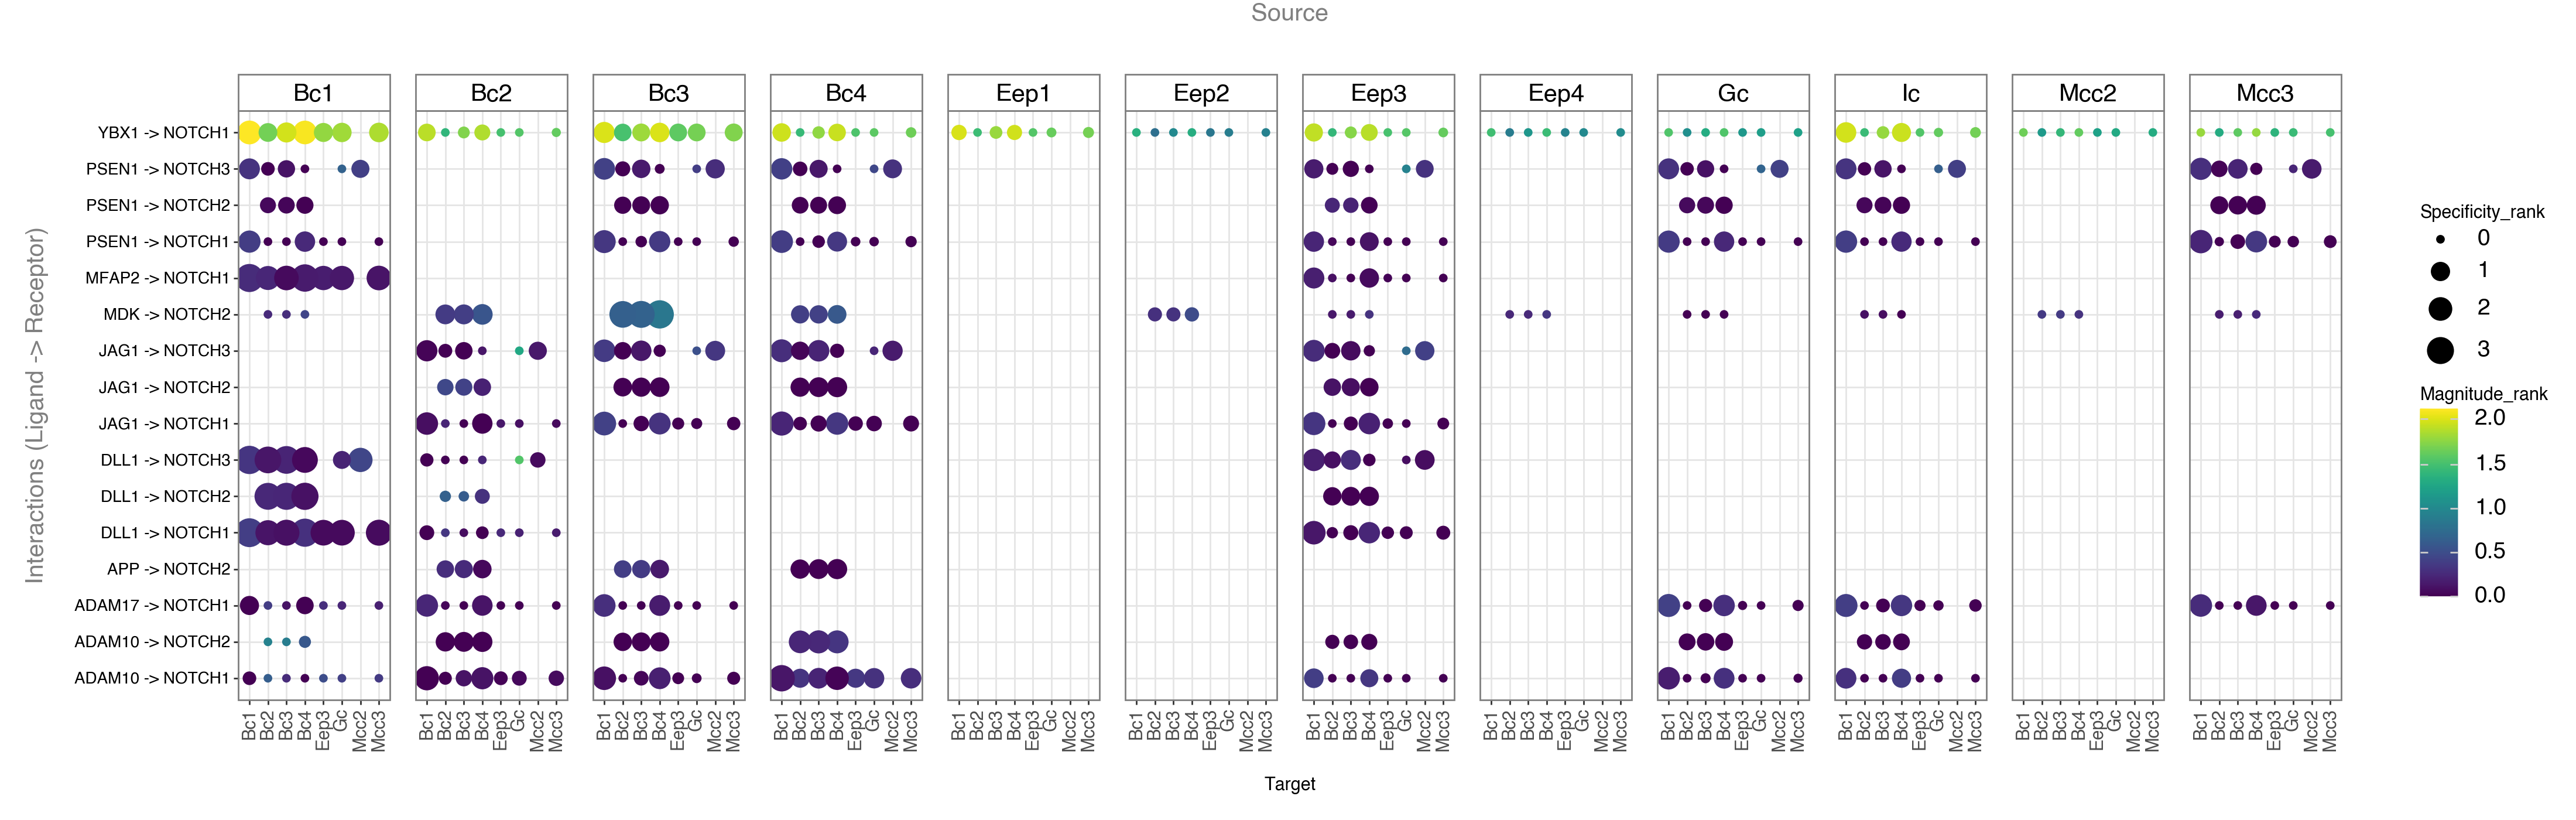

In [ ]:
dot_notch_p = li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=["NOTCH1", "NOTCH2", "NOTCH3"],
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    figure_size=(22, 7)
)
dot_notch_p
dot_notch_p.save('st22_notch_dotplot.png')

In [ ]:
### RESULTS ###
#  This dotplot shows the top Notch-associated ligand–receptor interactions from the stage 22 LIANA rank-aggregate results. Dot colour reflects magnitude_rank and dot size reflects specificity_rank, so larger and brighter dots indicate interactions that are ranked as stronger and more specific across the integrated LIANA methods. 
# The plot suggests that Notch-related signaling at stage 22 is not uniformly distributed across all clusters, but is instead concentrated mainly in basal-associated clusters (Bc1–Bc4), with additional restricted signal in Gc, Ic, Eep3, and Mcc3. 
# This pattern is consistent with stage 22 representing an early tailbud specialization state, where communication is becoming more cluster-restricted rather than broadly progenitor-like. The clearest biologically defensible Notch pattern is the presence of canonical ligand–receptor pairs such as DLL1/JAG1 with NOTCH receptors, especially around basal-related states. 
# This suggests that Notch signaling is still active at stage 22, but mainly in a localized developmental and epithelial-patterning context, rather than acting as a dominant global signaling axis across the whole tissue.

In [30]:
# Check st22 Notch genes against LIANA consensus resource  #
resource = li.rs.select_resource("consensus")
lr_genes = set(resource["ligand"]).union(set(resource["receptor"]))

paper_human = set(notch_st22_genes)

print("In data:", sorted(set(paper_human) & set(adata_st22.var_names)))
print("In LR resource:", sorted(set(paper_human) & lr_genes))
print("In both:", sorted(set(paper_human) & set(adata_st22.var_names) & lr_genes))

In data: ['DLL1', 'DTX1', 'DTX2', 'JAG2', 'MAML3', 'NCSTN', 'NOTCH2']
In LR resource: ['DLL1', 'JAG2', 'NCSTN', 'NOTCH2']
In both: ['DLL1', 'JAG2', 'NCSTN', 'NOTCH2']


In [ ]:
### WNT ###

In [31]:
# Wnt table from TableS7 #
wnt_table = signalling_df.loc[signalling_df["pathway"] == "Wnt"].copy()
wnt_table.head()

,pathway,xeno_symbol,cell_type,stage
49,Wnt,fzd4.L,P2,st08
50,Wnt,nkd1.L,P2,st08
51,Wnt,porcn.L,P2,st08
52,Wnt,ccnd2.L,P2,st08
53,Wnt,ctbp2.S,P2,st08


In [32]:
wnt_found = (
    wnt_table
    .merge(gene_map, on="xeno_symbol", how="inner")
    [["stage", "cell_type", "xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .sort_values(["stage", "cell_type", "xeno_symbol"])
    .reset_index(drop=True)
)

wnt_found.head(20)

,stage,cell_type,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
0,st08,Bc1,tcf7l2.L,TCF7L2
1,st08,Eep4,chp1.L,CHP1
2,st08,Ic,daam1.S,DAAM1
3,st08,Mcc2,ppp2cb.L,PPP2CB
4,st08,Mcc3,ppp2r1a.L,PPP2R1A
5,st08,Mcc3,tbl1x.L,TBL1X
6,st08,P2,ccnd2.L,CCND2
7,st08,P2,csnk1e.L,CSNK1E
8,st08,P2,csnk1e.S,CSNK1E
9,st08,P2,ctbp1.S,CTBP1


In [33]:
wnt_st22_genes = (
    wnt_found.loc[wnt_found["stage"] == "st22", "ORTHOLOG_HUMAN_SYMBOL"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("=== Stage 22 TableS7-derived Wnt genes (mapped to human) ===")
print(sorted(wnt_st22_genes))

=== Stage 22 TableS7-derived Wnt genes (mapped to human) ===
['CAMK2G', 'DKK1', 'FZD10', 'FZD8', 'JUN', 'LEF1', 'LRP5', 'MYC', 'NFAT5', 'NFATC1', 'PLCB4', 'PPARD', 'PPP3R1', 'RHOC', 'VANGL1', 'WNT2B', 'WNT4', 'WNT8A']


In [34]:
def extract_pathway_hits(res_df, pathway_genes):
    pathway_genes = sorted(set(pathway_genes))

    mask = (
        res_df["ligand_complex"].isin(pathway_genes) |
        res_df["receptor_complex"].isin(pathway_genes)
    )

    pathway_hits = (
        res_df.loc[mask]
        .copy()
        .sort_values(["magnitude_rank", "specificity_rank"])
        .reset_index(drop=True)
    )

    return pathway_hits

def summarize_pathway_hits(pathway_name, pathway_hits):
    print(f"{pathway_name} LIANA rows: {len(pathway_hits)}")
    print(f"{pathway_name} unique ligand-receptor pairs:",
          pathway_hits[["ligand_complex", "receptor_complex"]].drop_duplicates().shape[0])
    print(f"{pathway_name} unique source-target-LR combinations:",
          pathway_hits[["source", "target", "ligand_complex", "receptor_complex"]].drop_duplicates().shape[0])

wnt_hits_st22 = extract_pathway_hits(res, wnt_st22_genes)
summarize_pathway_hits("Wnt", wnt_hits_st22)

wnt_hits_st22.head(20)

Wnt LIANA rows: 15
Wnt unique ligand-receptor pairs: 5
Wnt unique source-target-LR combinations: 15


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
0,Bc1,Bc1,FAM3B,LRP5,0.003015,1.000,0.000009,-0.220269,-0.098755,0.000425,0.157178,1.000000,0.013734
1,Bc3,Bc1,THBS1,LRP5,0.003866,0.028,0.000015,0.039500,0.002994,0.040137,0.191990,0.320088,0.070960
2,Bc2,Bc1,THBS1,LRP5,0.004469,0.062,0.000019,0.058164,0.003437,0.051058,0.211351,0.289942,0.156748
3,Mcc2,Bc1,FAM3B,LRP5,0.139411,0.010,0.000909,0.442686,0.160918,0.042901,0.651955,0.016611,0.307348
4,Mcc3,Bc1,FAM3B,LRP5,0.137887,0.000,0.000899,0.435277,0.156820,0.042426,0.650692,0.009079,0.313939
5,Gc,Bc1,FAM3B,LRP5,0.119869,0.000,0.000780,0.347701,0.143828,0.036815,0.634403,0.009079,0.382412
6,Ic,Bc1,FAM3B,LRP5,0.110254,0.000,0.000717,0.300966,0.093290,0.033821,0.624510,0.009079,0.430289
7,Bc1,Bc1,WNT8A,FZD7_LRP5,0.006429,0.000,0.000032,0.202148,0.008100,0.129548,0.258658,0.047722,0.570223
8,Bc1,Bc1,WNT8A,FZD10_LRP5,0.006429,0.000,0.000032,0.202148,0.008100,0.129548,0.258658,0.047722,0.570223
9,Bc1,Bc1,WNT8A,FZD2_LRP5,0.006429,0.000,0.000032,0.202148,0.008100,0.129548,0.258658,0.047722,0.570223


In [35]:
wnt_hits_st22.to_csv("st22_wnt_hits_from_TableS7_phenograph.csv", index=False)
print("Saved Wnt hits.")

Saved Wnt hits.


Wnt receptors in hits: ['FZD10_LRP5', 'FZD2_LRP5', 'FZD7_LRP5', 'LRP5']


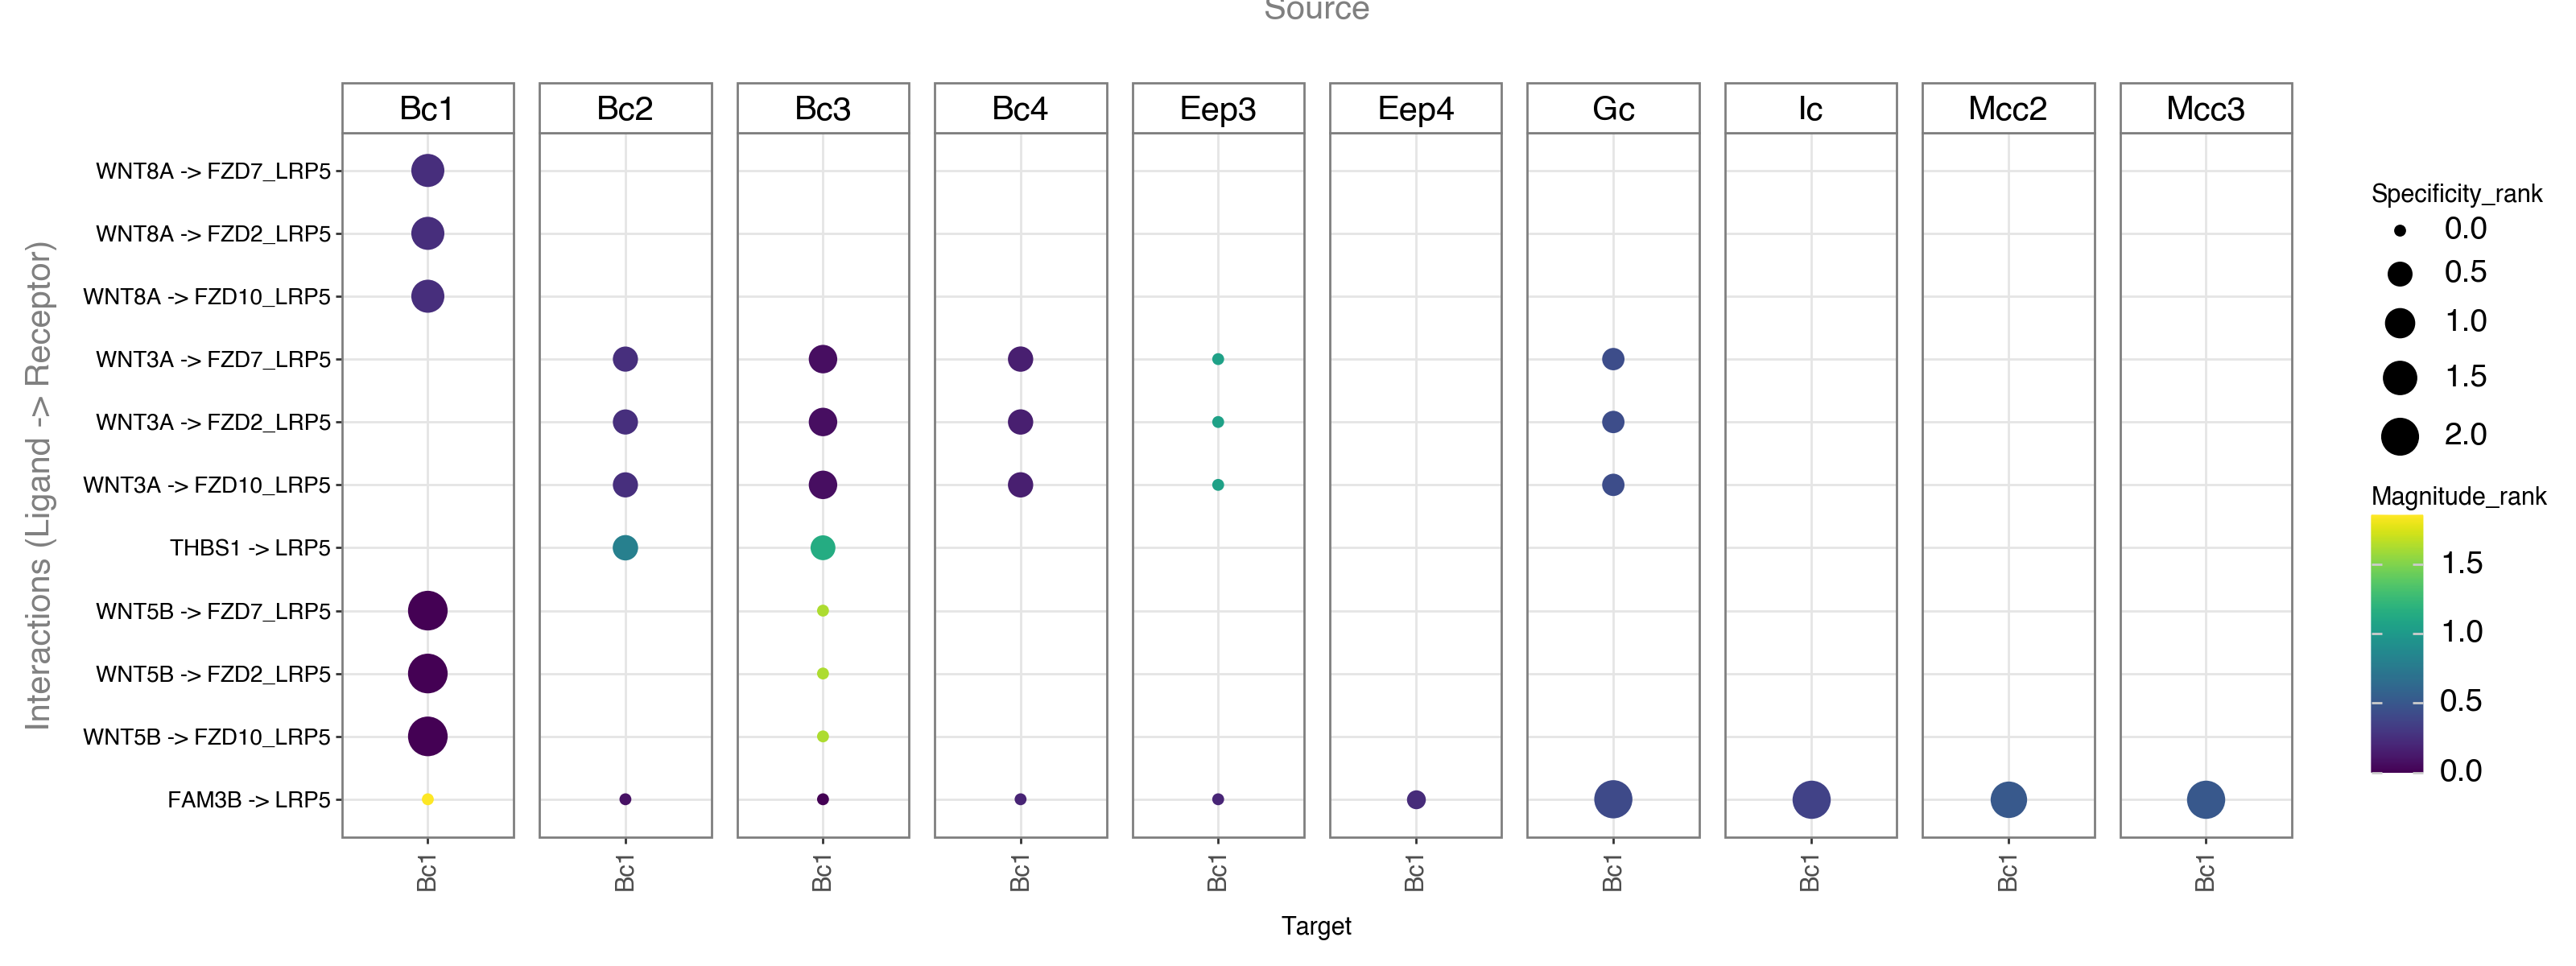

In [36]:
# Wnt receptor complexes actually present in the extracted Wnt hits
wnt_receptors_in_hits = sorted(
    wnt_hits_st22["receptor_complex"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("Wnt receptors in hits:", wnt_receptors_in_hits)

wnt_dot_p = li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=wnt_receptors_in_hits,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    top_n=15,
    orderby="magnitude_rank",
    orderby_ascending=True,
    figure_size=(16, 6)
)
wnt_dot_p

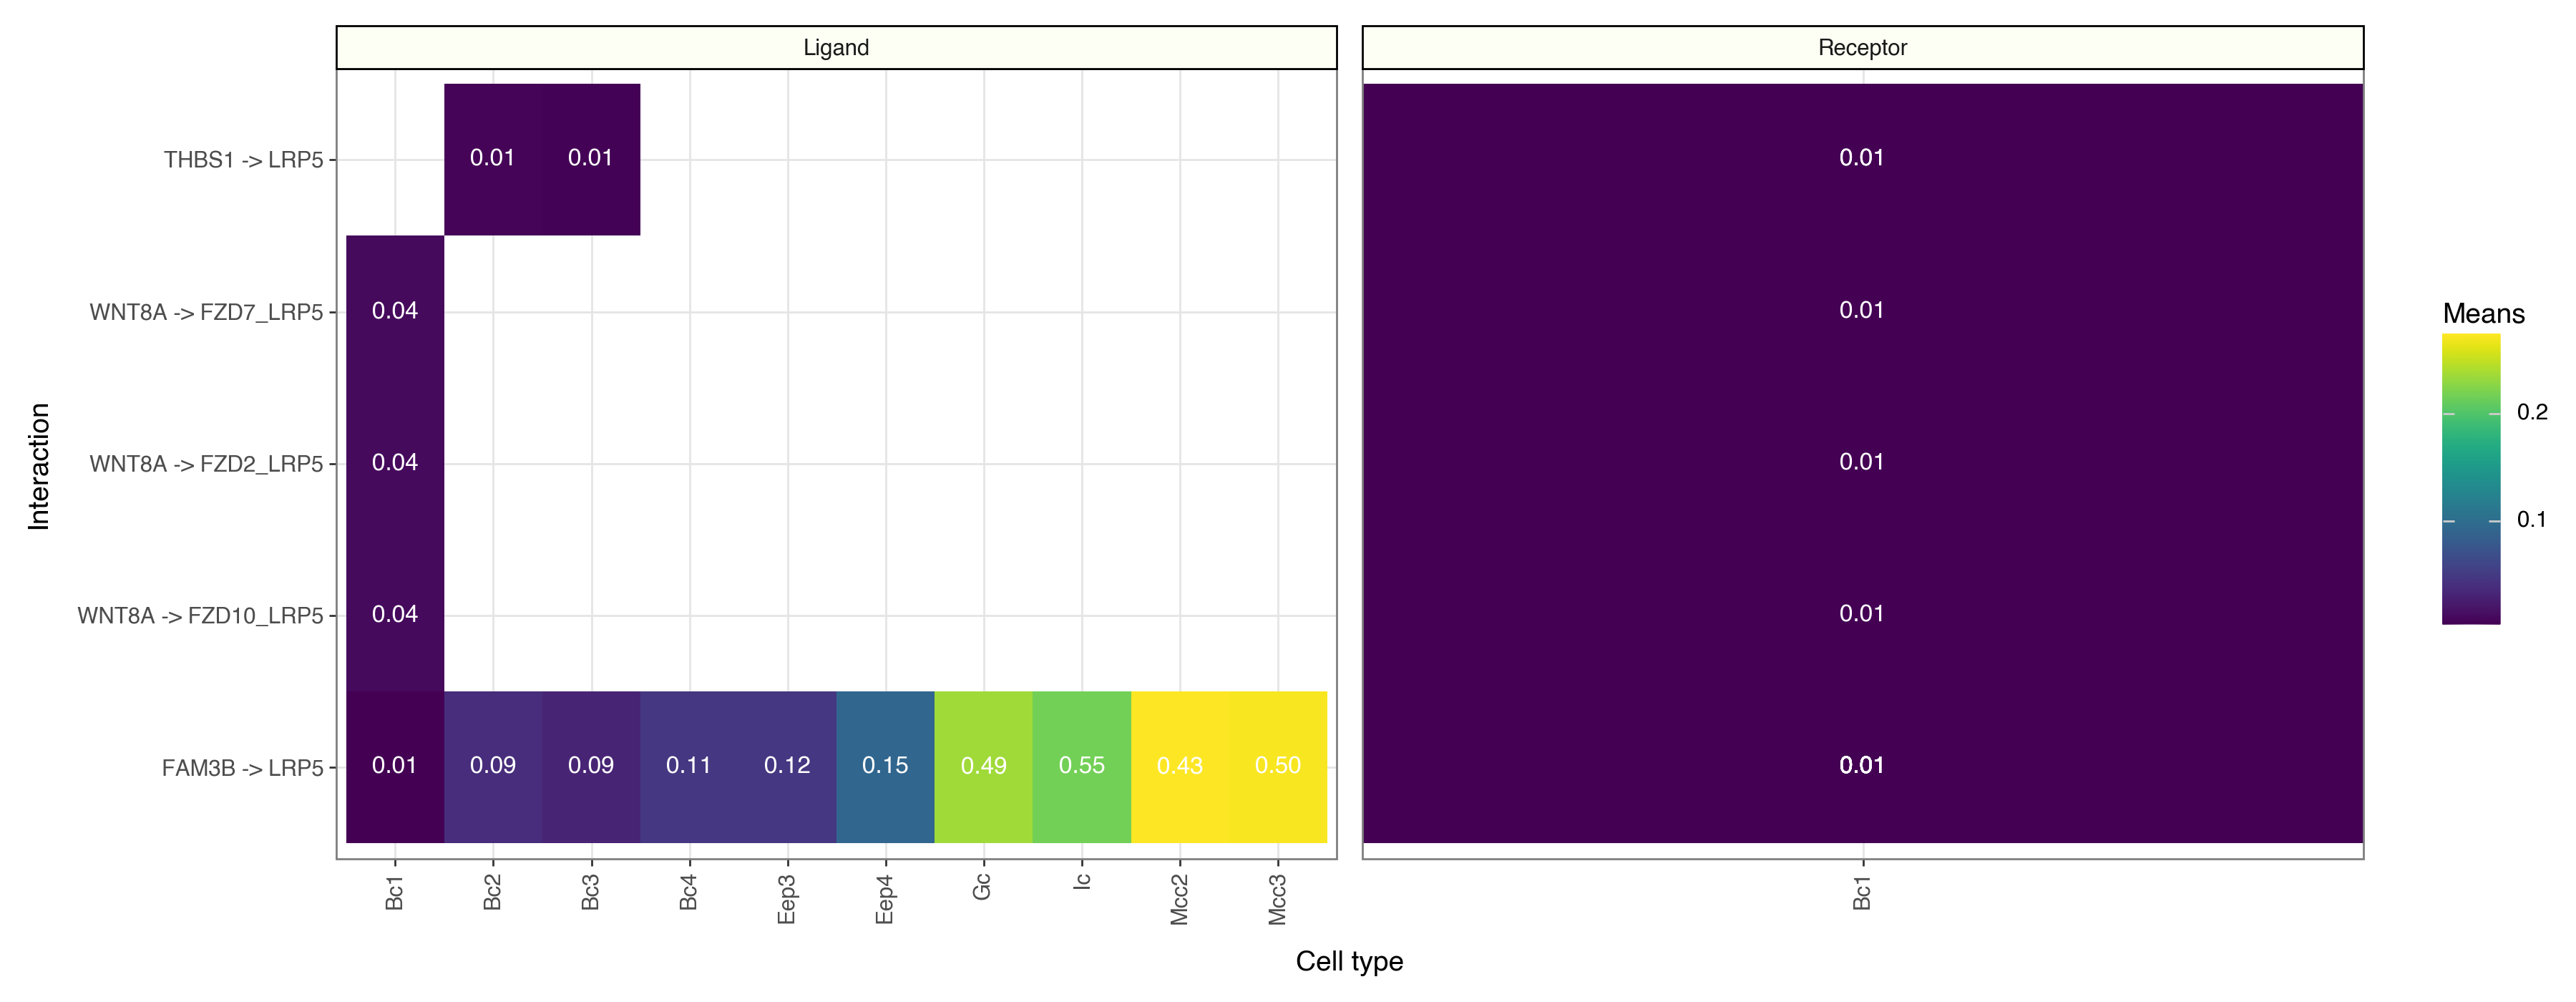

In [37]:
wnt_tile_p = li.pl.tileplot(
    adata=adata_st22,
    uns_key="cpdb_res",
    fill="means",
    label="props",
    label_fun=lambda x: f"{x:.2f}",
    top_n=15,
    orderby="cellphone_pvals",
    orderby_ascending=True,
    filter_fun=lambda x: (
        x["ligand_complex"] in set(wnt_st22_genes) or
        x["receptor_complex"] in set(wnt_st22_genes)
    ),
    source_title="Ligand",
    target_title="Receptor",
    figure_size=(18, 7)
)
wnt_tile_p

In [38]:
wnt_dot_p.save("st22_wnt_dotplot.png", dpi=300)
wnt_tile_p.save("st22_wnt_tileplot.png", dpi=300)

print("Saved Wnt plots.")

/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 6 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: st22_wnt_dotplot.png
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 18 x 7 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: st22_wnt_tileplot.png


Saved Wnt plots.


In [ ]:
### TGF-B ###

In [39]:
# TGF-B table from TableS7 #
tgfb_table = signalling_df.loc[signalling_df["pathway"] == "TGF-B"].copy()
tgfb_table.head()

,pathway,xeno_symbol,cell_type,stage
187,TGF-B,smad1.L,P2,st08
188,TGF-B,bmp2.L,P2,st08
189,TGF-B,smad2.L,P2,st08
190,TGF-B,bmp7.2.S,P2,st08
191,TGF-B,bmp2.S,P2,st08


In [40]:
tgfb_found = (
    tgfb_table
    .merge(gene_map, on="xeno_symbol", how="inner")
    [["stage", "cell_type", "xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .sort_values(["stage", "cell_type", "xeno_symbol"])
    .reset_index(drop=True)
)

tgfb_found.head(20)

,stage,cell_type,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
0,st08,Bc3,smad6.L,SMAD6
1,st08,Bc3,smad6.S,SMAD6
2,st08,Mcc2,ppp2cb.L,PPP2CB
3,st08,Mcc3,ppp2r1a.L,PPP2R1A
4,st08,P2,bmp2.L,BMP2
5,st08,P2,bmp2.S,BMP2
6,st08,P2,bmp7.2.S,BMP7
7,st08,P2,smad1.L,SMAD1
8,st08,P2,smad2.L,SMAD2
9,st10.5,Bc3,mapk1.L,MAPK1


In [41]:
tgfb_st22_genes = (
    tgfb_found.loc[tgfb_found["stage"] == "st22", "ORTHOLOG_HUMAN_SYMBOL"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("=== Stage 22 TableS7-derived TGF-B genes (mapped to human) ===")
print(sorted(tgfb_st22_genes))

=== Stage 22 TableS7-derived TGF-B genes (mapped to human) ===
['BMP4', 'MYC', 'RPS6KB1', 'SMAD3', 'SMAD7', 'SMAD9']


In [42]:
tgfb_hits_st22 = extract_pathway_hits(res, tgfb_st22_genes)
summarize_pathway_hits("TGF-B", tgfb_hits_st22)

tgfb_hits_st22.head(20)

TGF-B LIANA rows: 90
TGF-B unique ligand-receptor pairs: 2
TGF-B unique source-target-LR combinations: 90


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
0,Bc4,Bc1,BMP4,ACVR2A_BMPR1A,0.057616,0.002,0.001085,0.186526,0.046629,0.046562,0.671779,0.005948,0.237532
1,Bc4,Gc,BMP4,ACVR2A_BMPR1A,0.057125,0.003,0.000982,0.127645,0.038432,0.012135,0.660693,0.221935,0.276515
2,Bc3,Bc1,BMP4,ACVR2A_BMPR1A,0.049103,0.000,0.000909,0.127371,0.046689,0.039004,0.651964,0.017845,0.306911
3,Bc4,Bc3,BMP4,ACVR2A_BMPR1A,0.056717,0.002,0.000897,0.169926,0.045169,0.038475,0.650412,0.015520,0.316591
4,Bc4,Bc1,BMP4,ACVR2B_BMPR1A,0.056516,0.002,0.000855,0.225081,0.049461,0.073333,0.644904,0.005948,0.339497
5,Bc3,Gc,BMP4,ACVR2A_BMPR1A,0.048612,0.000,0.000823,0.068489,0.038492,0.010165,0.640566,0.303670,0.356978
6,Bc4,Bc2,BMP4,ACVR2A_BMPR1A,0.056360,0.001,0.000822,0.163328,0.044939,0.035260,0.640428,0.022657,0.358838
7,Mcc3,Ic,BMP4,ACVR2A_BMPR1A,0.005135,1.000,0.000026,-0.205983,-0.050449,0.001125,0.241358,1.000000,0.392771
8,Bc4,Mcc3,BMP4,ACVR2A_BMPR1A,0.056079,0.002,0.000763,0.158138,0.044518,0.032732,0.631818,0.032341,0.395869
9,Bc3,Bc3,BMP4,ACVR2A_BMPR1A,0.048205,0.000,0.000751,0.110771,0.045229,0.032229,0.630017,0.033476,0.402664


In [43]:
tgfb_hits_st22.to_csv("st22_tgfb_hits_from_TableS7_phenograph.csv", index=False)
print("Saved TGF-B hits.")

Saved TGF-B hits.


TGF-B receptors in hits: ['ACVR2A_BMPR1A', 'ACVR2B_BMPR1A']


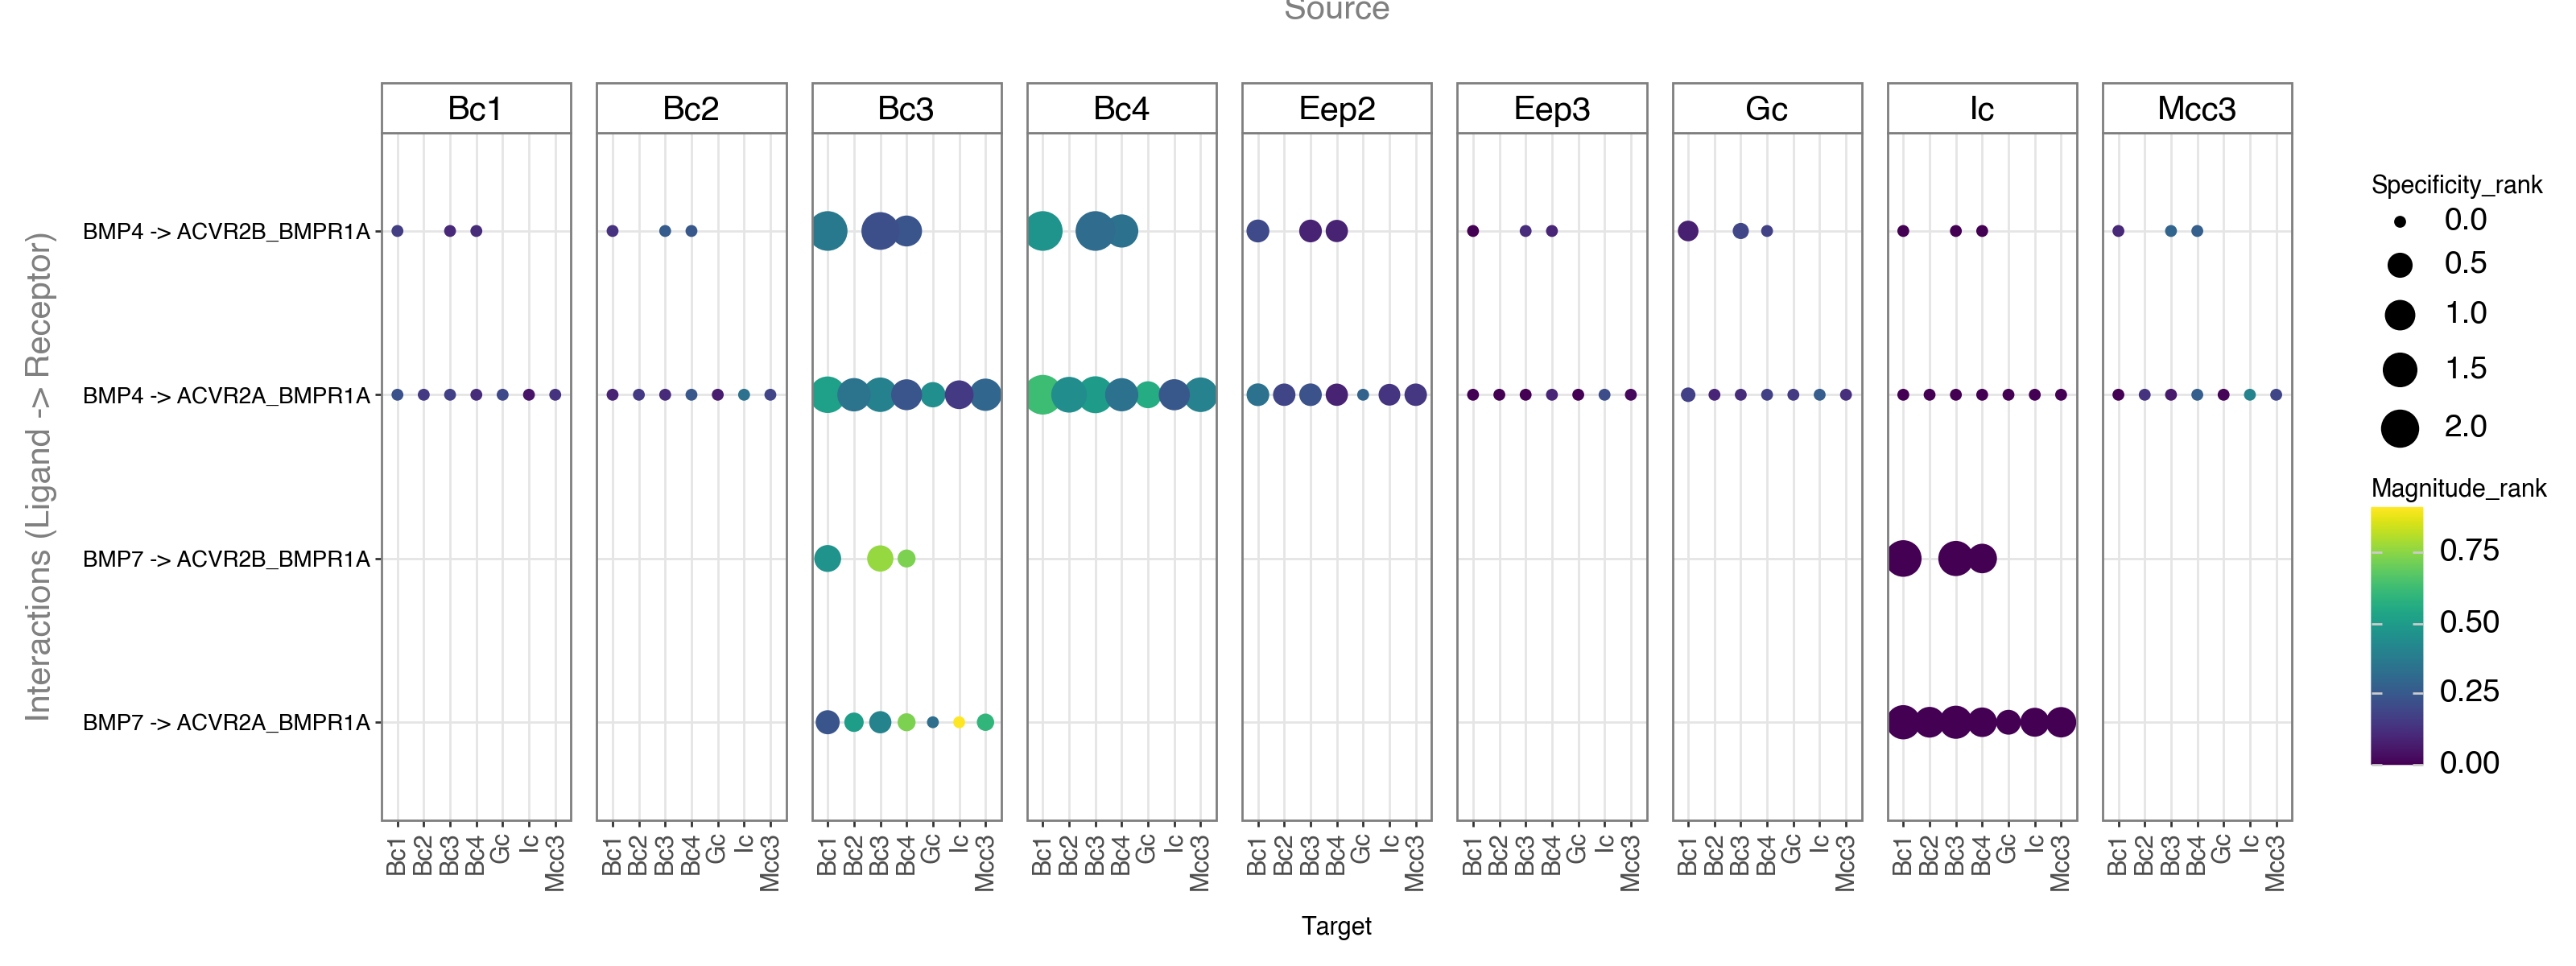

In [44]:
# TGF-B receptor complexes actually present in the extracted TGF-B hits
tgfb_receptors_in_hits = sorted(
    tgfb_hits_st22["receptor_complex"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print("TGF-B receptors in hits:", tgfb_receptors_in_hits)

tgfb_dot_p = li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=tgfb_receptors_in_hits,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    top_n=20,
    orderby="magnitude_rank",
    orderby_ascending=True,
    figure_size=(16, 6)
)
tgfb_dot_p

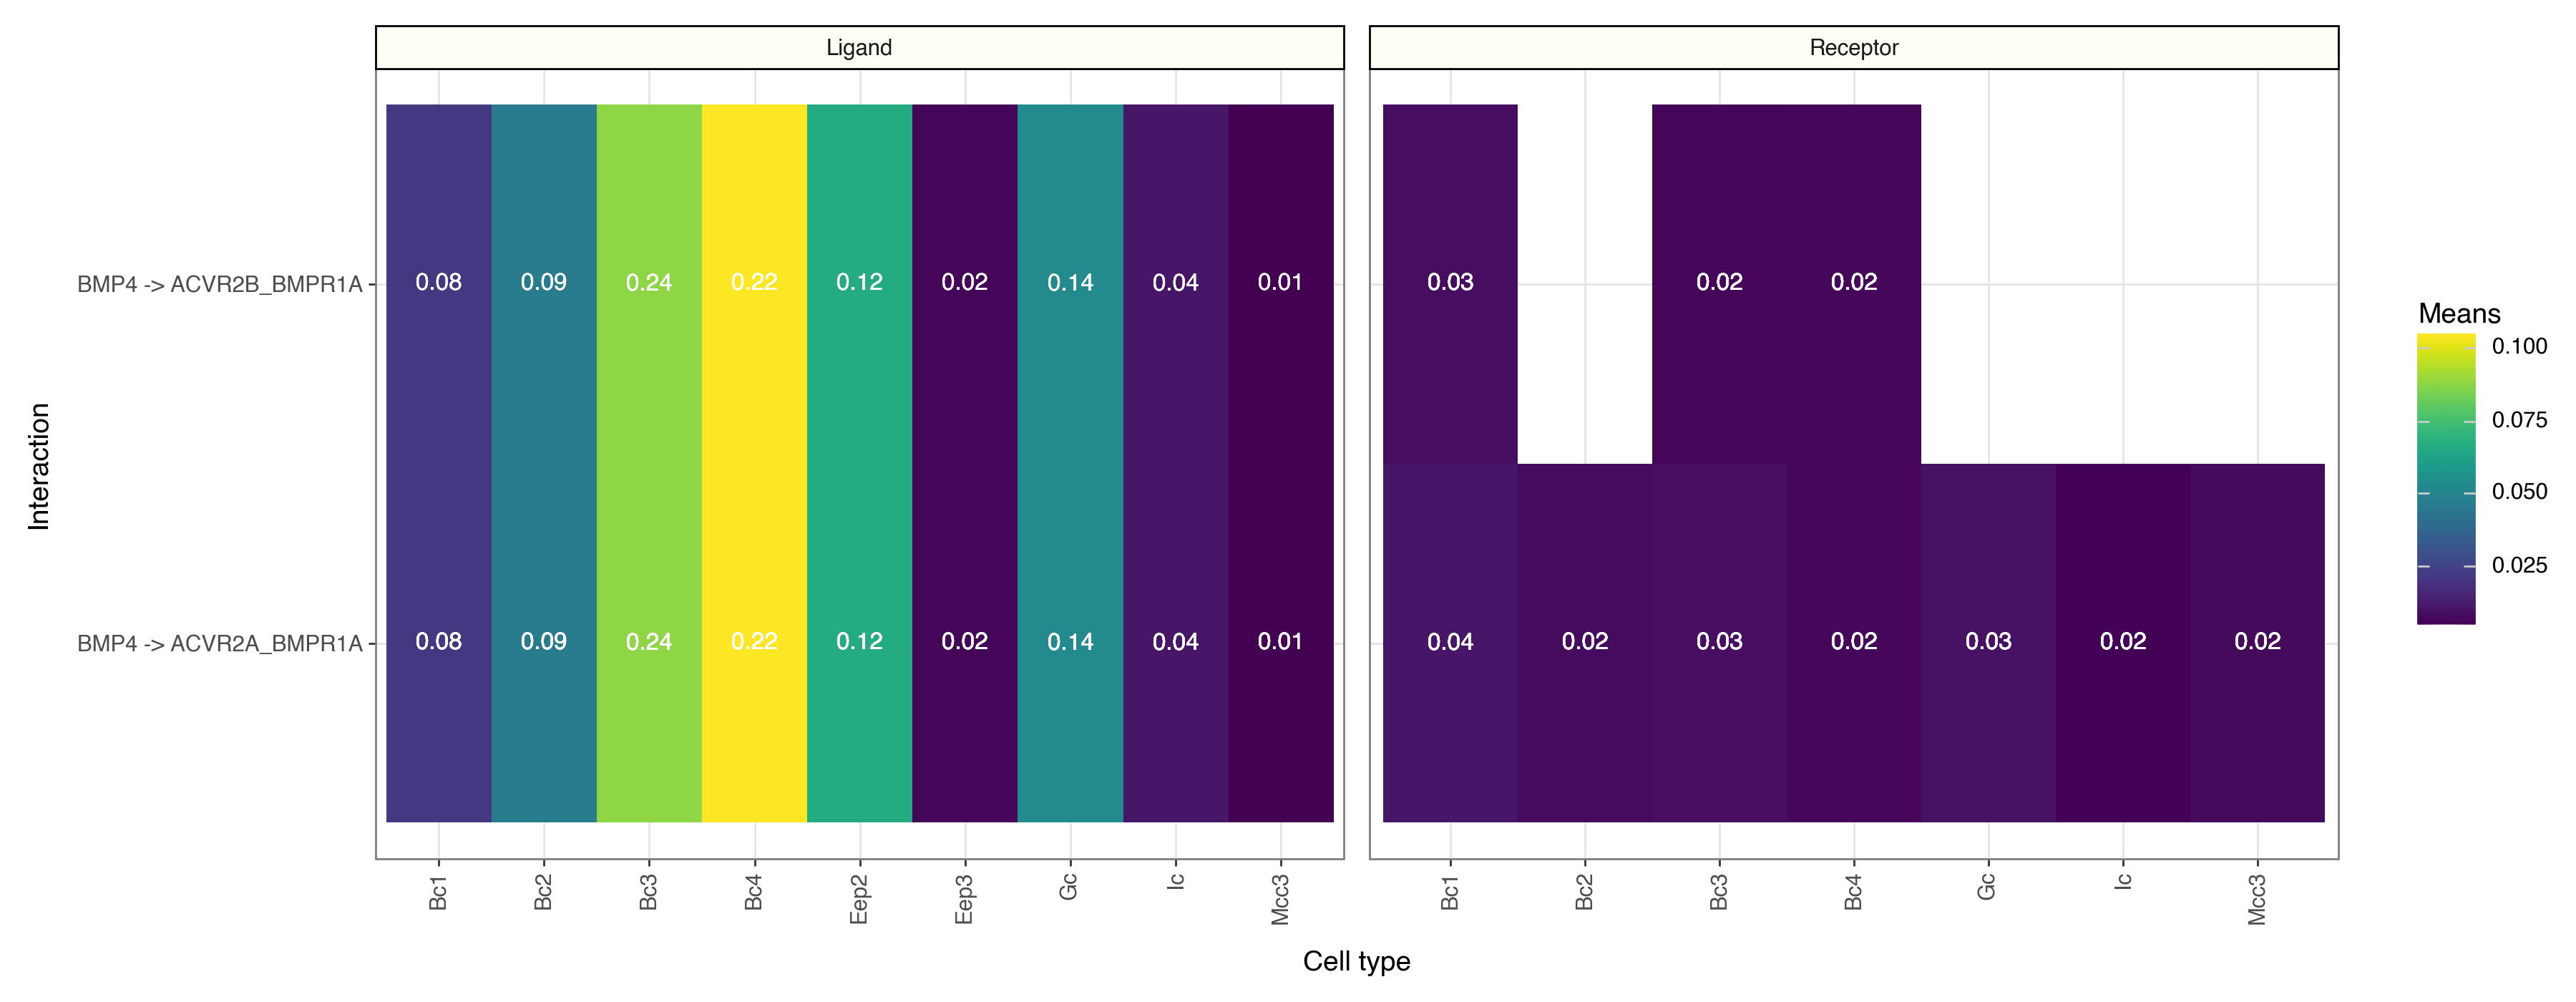

In [45]:
tgfb_tile_p = li.pl.tileplot(
    adata=adata_st22,
    uns_key="cpdb_res",
    fill="means",
    label="props",
    label_fun=lambda x: f"{x:.2f}",
    top_n=20,
    orderby="cellphone_pvals",
    orderby_ascending=True,
    filter_fun=lambda x: (
        x["ligand_complex"] in set(tgfb_st22_genes) or
        x["receptor_complex"] in set(tgfb_st22_genes)
    ),
    source_title="Ligand",
    target_title="Receptor",
    figure_size=(18, 7)
)
tgfb_tile_p

In [46]:
tgfb_dot_p.save("st22_tgfb_dotplot.png", dpi=300)
tgfb_tile_p.save("st22_tgfb_tileplot.png", dpi=300)

print("Saved TGF-B plots.")

/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 6 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: st22_tgfb_dotplot.png
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 18 x 7 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: st22_tgfb_tileplot.png


Saved TGF-B plots.


In [47]:
resource = li.rs.select_resource("consensus")
consensus_genes = set(resource["ligand"]).union(set(resource["receptor"]))

def get_stage_supported_genes(found_df, stage="st22"):
    stage_genes = (
        found_df.loc[found_df["stage"] == stage, "ORTHOLOG_HUMAN_SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )
    supported_genes = sorted(set(stage_genes) & consensus_genes)
    return stage_genes, supported_genes

# Notch
notch_st22_genes, notch_supported_genes = get_stage_supported_genes(notch_found, stage="st22")
print("Notch st22 genes:", len(notch_st22_genes))
print("Notch genes supported in consensus:", len(notch_supported_genes))
print(notch_supported_genes)

# Wnt
wnt_st22_genes, wnt_supported_genes = get_stage_supported_genes(wnt_found, stage="st22")
print("\nWnt st22 genes:", len(wnt_st22_genes))
print("Wnt genes supported in consensus:", len(wnt_supported_genes))
print(wnt_supported_genes)

# TGF-B
tgfb_st22_genes, tgfb_supported_genes = get_stage_supported_genes(tgfb_found, stage="st22")
print("\nTGF-B st22 genes:", len(tgfb_st22_genes))
print("TGF-B genes supported in consensus:", len(tgfb_supported_genes))
print(tgfb_supported_genes)

Notch st22 genes: 7
Notch genes supported in consensus: 4
['DLL1', 'JAG2', 'NCSTN', 'NOTCH2']

Wnt st22 genes: 18
Wnt genes supported in consensus: 7
['DKK1', 'FZD10', 'FZD8', 'LRP5', 'WNT2B', 'WNT4', 'WNT8A']

TGF-B st22 genes: 6
TGF-B genes supported in consensus: 1
['BMP4']
